# 🔥 PyTorch & TensorFlow Basics — Complete Tutorial

Welcome! This notebook teaches you the fundamentals of both **PyTorch** and **TensorFlow/Keras** side by side.

### 📚 What You'll Learn
| Topic | PyTorch | TensorFlow/Keras |
|-------|---------|------------------|
| Tensors & Arrays | `torch.Tensor` | `tf.Tensor` |
| Autograd / Gradients | `torch.autograd` | `tf.GradientTape` |
| Building Models | `nn.Module` | `keras.Sequential` |
| Training Loop | Manual loop | `.fit()` API |
| Save & Load | `torch.save` | `model.save` |

### 🗂️ Notebook Structure
1. Installation & Setup
2. Tensors — the building blocks
3. Tensor Operations & Math
4. Autograd (Automatic Differentiation)
5. Building Neural Networks
6. Training on Real Data
7. Evaluation & Metrics
8. Saving & Loading Models
9. ✅ Practice Tasks (with solutions)

> **Tip:** Run each cell top-to-bottom using `Shift+Enter`.

---
## 1. 📦 Installation & Setup

In [1]:
# Install required libraries (run once)
!pip install torch torchvision torchaudio --quiet
!pip install tensorflow --quiet
!pip install matplotlib numpy scikit-learn --quiet
print("✅ All packages installed!")

✅ All packages installed!


In [2]:
# ── Core imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Version check
print(f"PyTorch version   : {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available (PyTorch): {torch.cuda.is_available()}")
print(f"GPU available (TF)     : {len(tf.config.list_physical_devices('GPU')) > 0}")

PyTorch version   : 2.11.0+cpu
TensorFlow version: 2.21.0
GPU available (PyTorch): False
GPU available (TF)     : False


---
## 2. 🧱 Tensors — The Building Blocks

A **tensor** is a multi-dimensional array — the fundamental data structure in both frameworks.

| Dimensions | Name | Example shape |
|-----------|------|---------------|
| 0-D | Scalar | `()` |
| 1-D | Vector | `(3,)` |
| 2-D | Matrix | `(3, 4)` |
| 3-D | Tensor | `(2, 3, 4)` |

In [3]:
# ════════════════════════════════════
#  PyTorch — Creating Tensors
# ════════════════════════════════════

# From Python lists
pt_scalar = torch.tensor(42.0)
pt_vector = torch.tensor([1.0, 2.0, 3.0])
pt_matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# Special tensors
pt_zeros   = torch.zeros(3, 4)       # all zeros
pt_ones    = torch.ones(2, 3)        # all ones
pt_rand    = torch.rand(2, 3)        # uniform [0, 1)
pt_randn   = torch.randn(2, 3)       # standard normal N(0,1)
pt_eye     = torch.eye(3)            # identity matrix
pt_arange  = torch.arange(0, 10, 2) # like range()

print("── PyTorch Tensors ──")
print(f"Scalar : {pt_scalar}  | shape: {pt_scalar.shape}")
print(f"Vector : {pt_vector}  | shape: {pt_vector.shape}")
print(f"Matrix shape: {pt_matrix.shape}")
print(f"Zeros :\n{pt_zeros}")
print(f"Random (uniform):\n{pt_rand.numpy().round(3)}")
print(f"Arange: {pt_arange}")

── PyTorch Tensors ──
Scalar : 42.0  | shape: torch.Size([])
Vector : tensor([1., 2., 3.])  | shape: torch.Size([3])
Matrix shape: torch.Size([3, 2])
Zeros :
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Random (uniform):
[[0.362 0.966 0.951]
 [0.549 0.982 0.634]]
Arange: tensor([0, 2, 4, 6, 8])


In [4]:
# ════════════════════════════════════
#  TensorFlow — Creating Tensors
# ════════════════════════════════════

# From Python lists
tf_scalar = tf.constant(42.0)
tf_vector = tf.constant([1.0, 2.0, 3.0])
tf_matrix = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# Special tensors
tf_zeros  = tf.zeros([3, 4])
tf_ones   = tf.ones([2, 3])
tf_rand   = tf.random.uniform([2, 3])
tf_randn  = tf.random.normal([2, 3])
tf_eye    = tf.eye(3)
tf_range  = tf.range(0, 10, 2)

print("── TensorFlow Tensors ──")
print(f"Scalar : {tf_scalar.numpy()}  | shape: {tf_scalar.shape}")
print(f"Vector : {tf_vector.numpy()}  | shape: {tf_vector.shape}")
print(f"Matrix shape: {tf_matrix.shape}")
print(f"Random (uniform):\n{tf_rand.numpy().round(3)}")
print(f"Range: {tf_range.numpy()}")

── TensorFlow Tensors ──
Scalar : 42.0  | shape: ()
Vector : [1. 2. 3.]  | shape: (3,)
Matrix shape: (3, 2)
Random (uniform):
[[0.973 0.295 0.044]
 [0.364 0.23  0.776]]
Range: [0 2 4 6 8]


In [5]:
# ── Indexing & Slicing (same in both!) ─────────────────────────
t = torch.tensor([[10, 20, 30],
                   [40, 50, 60],
                   [70, 80, 90]])

print("Full tensor:\n", t.numpy())
print("Row 0     :", t[0].numpy())          # first row
print("Col 1     :", t[:, 1].numpy())       # second column
print("Element[1,2]:", t[1, 2].item())      # scalar value
print("Sub-matrix  :\n", t[0:2, 1:3].numpy())  # slice

# Reshape
flat   = t.reshape(-1)         # flatten to 1D
reshaped = t.reshape(1, 9)     # shape (1, 9)
print("Flattened :", flat.numpy())
print("Reshaped  :", reshaped.numpy())

Full tensor:
 [[10 20 30]
 [40 50 60]
 [70 80 90]]
Row 0     : [10 20 30]
Col 1     : [20 50 80]
Element[1,2]: 60
Sub-matrix  :
 [[20 30]
 [50 60]]
Flattened : [10 20 30 40 50 60 70 80 90]
Reshaped  : [[10 20 30 40 50 60 70 80 90]]


---
## 3. ➕ Tensor Operations & Math

All the standard mathematical operations are available element-wise or as matrix operations.

In [6]:
# ════════════════════════════════════
#  PyTorch — Operations
# ════════════════════════════════════
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("── Element-wise Arithmetic ──")
print("a + b =", (a + b).numpy())
print("a - b =", (a - b).numpy())
print("a * b =", (a * b).numpy())      # element-wise multiply
print("a / b =", (a / b).numpy())
print("a ** 2 =", (a ** 2).numpy())    # power

print("\n── Reduction Operations ──")
print("sum :", a.sum().item())
print("mean:", a.mean().item())
print("max :", a.max().item())
print("min :", a.min().item())
print("std :", a.std().item())

print("\n── Matrix Multiplication ──")
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
print("A @ B =\n", (A @ B).numpy())          # matrix multiply
print("dot product a·b =", torch.dot(a, b).item())

print("\n── Math Functions ──")
print("sqrt(a)  =", torch.sqrt(a).numpy())
print("exp(a)   =", torch.exp(a).numpy().round(3))
print("log(a)   =", torch.log(a).numpy().round(3))
print("abs(-a)  =", torch.abs(-a).numpy())

── Element-wise Arithmetic ──
a + b = [5. 7. 9.]
a - b = [-3. -3. -3.]
a * b = [ 4. 10. 18.]
a / b = [0.25 0.4  0.5 ]
a ** 2 = [1. 4. 9.]

── Reduction Operations ──
sum : 6.0
mean: 2.0
max : 3.0
min : 1.0
std : 1.0

── Matrix Multiplication ──
A @ B =
 [[19. 22.]
 [43. 50.]]
dot product a·b = 32.0

── Math Functions ──
sqrt(a)  = [1.        1.4142135 1.7320508]
exp(a)   = [ 2.718  7.389 20.086]
log(a)   = [0.    0.693 1.099]
abs(-a)  = [1. 2. 3.]


In [7]:
# ════════════════════════════════════
#  TensorFlow — Operations
# ════════════════════════════════════
a_tf = tf.constant([1.0, 2.0, 3.0])
b_tf = tf.constant([4.0, 5.0, 6.0])

print("── Element-wise Arithmetic ──")
print("a + b =", tf.add(a_tf, b_tf).numpy())
print("a * b =", tf.multiply(a_tf, b_tf).numpy())
print("a ** 2 =", tf.pow(a_tf, 2).numpy())

print("\n── Reduction Operations ──")
print("sum :", tf.reduce_sum(a_tf).numpy())
print("mean:", tf.reduce_mean(a_tf).numpy())
print("max :", tf.reduce_max(a_tf).numpy())

print("\n── Matrix Multiplication ──")
A_tf = tf.constant([[1.0, 2.0], [3.0, 4.0]])
B_tf = tf.constant([[5.0, 6.0], [7.0, 8.0]])
print("A @ B =\n", tf.matmul(A_tf, B_tf).numpy())

print("\n── Math Functions ──")
print("sqrt(a) =", tf.sqrt(a_tf).numpy())
print("exp(a)  =", tf.exp(a_tf).numpy().round(3))
print("log(a)  =", tf.math.log(a_tf).numpy().round(3))

── Element-wise Arithmetic ──
a + b = [5. 7. 9.]
a * b = [ 4. 10. 18.]
a ** 2 = [1. 4. 9.]

── Reduction Operations ──
sum : 6.0
mean: 2.0
max : 3.0

── Matrix Multiplication ──
A @ B =
 [[19. 22.]
 [43. 50.]]

── Math Functions ──
sqrt(a) = [1.        1.4142135 1.7320508]
exp(a)  = [ 2.718  7.389 20.086]
log(a)  = [0.    0.693 1.099]


---
## 4. 🔄 Autograd — Automatic Differentiation

Autograd computes **gradients automatically**, which is the core of training neural networks via backpropagation.

Given a function `L = f(x)`, autograd computes `dL/dx` for you.

In [8]:
# ════════════════════════════════════
#  PyTorch — Autograd
# ════════════════════════════════════

# requires_grad=True tells PyTorch to track operations for this tensor
x = torch.tensor(3.0, requires_grad=True)

# Define a function:  y = x^2 + 2x + 1
y = x**2 + 2*x + 1
print(f"x = {x.item()},  y = {y.item()}")

# Compute gradient: dy/dx = 2x + 2
y.backward()                          # trigger backprop
print(f"dy/dx = {x.grad.item()}")     # should be 2(3)+2 = 8
print(f"Manual check: 2*{x.item()}+2 = {2*x.item()+2}")

print("\n── Multi-variable gradients ──")
# z = 3a^2 + ab  →  dz/da = 6a + b,  dz/db = a
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(5.0, requires_grad=True)
z = 3 * a**2 + a * b
z.backward()
print(f"dz/da = {a.grad.item()} (expected {6*2 + 5})")
print(f"dz/db = {b.grad.item()} (expected {2})")

x = 3.0,  y = 16.0
dy/dx = 8.0
Manual check: 2*3.0+2 = 8.0

── Multi-variable gradients ──
dz/da = 17.0 (expected 17)
dz/db = 2.0 (expected 2)


In [9]:
# ════════════════════════════════════
#  TensorFlow — GradientTape
# ════════════════════════════════════

# tf.Variable is tracked automatically inside a GradientTape
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2 + 2*x + 1

dy_dx = tape.gradient(y, x)
print(f"x = {x.numpy()},  y = {y.numpy()}")
print(f"dy/dx = {dy_dx.numpy()}  (expected 8)")

print("\n── Multi-variable gradients ──")
a = tf.Variable(2.0)
b = tf.Variable(5.0)
with tf.GradientTape() as tape:
    z = 3 * a**2 + a * b
grads = tape.gradient(z, [a, b])
print(f"dz/da = {grads[0].numpy()} (expected {6*2+5})")
print(f"dz/db = {grads[1].numpy()} (expected 2)")

x = 3.0,  y = 16.0
dy/dx = 8.0  (expected 8)

── Multi-variable gradients ──
dz/da = 17.0 (expected 17)
dz/db = 2.0 (expected 2)


---
## 5. 🧠 Building Neural Networks

A neural network is a stack of **layers**, each performing a linear transformation followed by a non-linear **activation function**.

```
Input → [Linear → Activation] × N → Output
```

Common activation functions: **ReLU**, **Sigmoid**, **Tanh**, **Softmax**

In [10]:
# ════════════════════════════════════
#  PyTorch — Building a Model with nn.Module
# ════════════════════════════════════

class SimpleNet(nn.Module):
    """
    A fully-connected network:
      Input(8) → Hidden(16) → Hidden(8) → Output(1)
    """
    def __init__(self):
        super().__init__()
        # Define layers
        self.net = nn.Sequential(
            nn.Linear(8, 16),   # input: 8 features → 16 neurons
            nn.ReLU(),
            nn.Linear(16, 8),   # 16 → 8
            nn.ReLU(),
            nn.Linear(8, 1),    # 8 → 1 output
            nn.Sigmoid()        # output in [0,1] for binary classification
        )

    def forward(self, x):
        return self.net(x)

pt_model = SimpleNet()
print("── PyTorch Model Architecture ──")
print(pt_model)

# Count parameters
total_params = sum(p.numel() for p in pt_model.parameters())
trainable    = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Test forward pass
dummy_input = torch.randn(4, 8)   # batch of 4 samples, each with 8 features
output = pt_model(dummy_input)
print(f"\nInput  shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output values: {output.detach().numpy().flatten().round(4)}")

── PyTorch Model Architecture ──
SimpleNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters    : 289
Trainable parameters: 289

Input  shape: torch.Size([4, 8])
Output shape: torch.Size([4, 1])
Output values: [0.4045 0.4148 0.3811 0.3916]


In [11]:
# ════════════════════════════════════
#  TensorFlow — Building a Model with Keras
# ════════════════════════════════════

tf_model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8,  activation='relu'),
    layers.Dense(1,  activation='sigmoid')
], name="SimpleNet")

print("── TensorFlow Model Architecture ──")
tf_model.summary()

# Test forward pass
dummy_tf = tf.random.normal([4, 8])
tf_out   = tf_model(dummy_tf)
print(f"\nOutput shape : {tf_out.shape}")
print(f"Output values: {tf_out.numpy().flatten().round(4)}")

── TensorFlow Model Architecture ──


Model: "SimpleNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)


Output shape : (4, 1)
Output values: [0.2968 0.2293 0.431  0.4609]


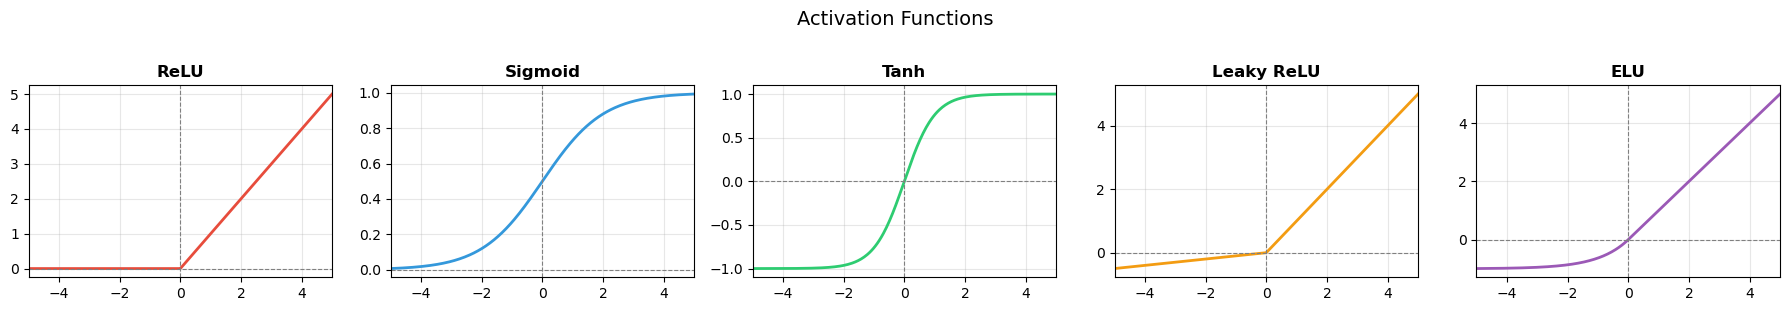

In [12]:
# ── Visualising Activation Functions ───────────────────────────
x_plot = np.linspace(-5, 5, 300)
x_t    = torch.tensor(x_plot, dtype=torch.float32)

activations = {
    'ReLU'    : torch.relu(x_t),
    'Sigmoid' : torch.sigmoid(x_t),
    'Tanh'    : torch.tanh(x_t),
    'Leaky ReLU': nn.functional.leaky_relu(x_t, 0.1),
    'ELU'     : nn.functional.elu(x_t),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for ax, (name, val), color in zip(axes, activations.items(), colors):
    ax.plot(x_plot, val.numpy(), color=color, lw=2)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlim(-5, 5)
    ax.grid(alpha=0.3)
plt.suptitle('Activation Functions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. 🚀 Training on Real Data

We'll train on the **Breast Cancer dataset** (binary classification) — predict malignant (1) vs benign (0).

### Training Loop Steps:
1. **Forward pass**: compute predictions
2. **Compute loss**: measure how wrong predictions are
3. **Backward pass**: compute gradients
4. **Update weights**: apply optimizer step
5. **Zero gradients** (PyTorch only): prevent accumulation

In [14]:
# ── Data Preparation (shared by both frameworks) ───────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data   = load_breast_cancer()
X, y   = data.data, data.target.astype(np.float32)

# Split into train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize: mean=0, std=1
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"Dataset   : Breast Cancer Wisconsin (Diagnostic)")
print(f"Features  : {X.shape[1]}")
print(f"Train size: {X_train.shape[0]}")
print(f"Test size : {X_test.shape[0]}")
print(f"Classes   : {dict(zip(data.target_names, np.bincount(data.target)))}")

Dataset   : Breast Cancer Wisconsin (Diagnostic)
Features  : 30
Train size: 455
Test size : 114
Classes   : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [15]:
# ════════════════════════════════════
#  PyTorch — Full Training Loop
# ════════════════════════════════════

# 1. Convert data to tensors
X_tr_pt = torch.tensor(X_train)
y_tr_pt = torch.tensor(y_train).unsqueeze(1)   # shape (N, 1)
X_te_pt = torch.tensor(X_test)
y_te_pt = torch.tensor(y_test).unsqueeze(1)

# 2. DataLoader (batching + shuffling)
train_ds = TensorDataset(X_tr_pt, y_tr_pt)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

# 3. Build model
class CancerNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

pt_cancer_model = CancerNet(X_train.shape[1])

# 4. Loss & Optimizer
criterion = nn.BCELoss()                              # Binary Cross Entropy
optimizer = optim.Adam(pt_cancer_model.parameters(), lr=1e-3)

# 5. Training Loop
EPOCHS = 50
pt_train_losses, pt_val_accs = [], []

for epoch in range(EPOCHS):
    pt_cancer_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()              # ① zero gradients
        preds = pt_cancer_model(X_batch)   # ② forward pass
        loss  = criterion(preds, y_batch)  # ③ compute loss
        loss.backward()                    # ④ backward pass
        optimizer.step()                   # ⑤ update weights
        epoch_loss += loss.item()

    # Validation accuracy
    pt_cancer_model.eval()
    with torch.no_grad():
        val_preds = pt_cancer_model(X_te_pt)
        val_acc   = ((val_preds > 0.5).float() == y_te_pt).float().mean().item()

    avg_loss = epoch_loss / len(train_dl)
    pt_train_losses.append(avg_loss)
    pt_val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\n✅ Final PyTorch Test Accuracy: {pt_val_accs[-1]:.4f}")

Epoch  10/50 | Loss: 0.1218 | Val Acc: 0.9825
Epoch  20/50 | Loss: 0.0576 | Val Acc: 0.9825
Epoch  30/50 | Loss: 0.0422 | Val Acc: 0.9912
Epoch  40/50 | Loss: 0.0415 | Val Acc: 0.9825
Epoch  50/50 | Loss: 0.0341 | Val Acc: 0.9737

✅ Final PyTorch Test Accuracy: 0.9737


In [16]:
# ════════════════════════════════════
#  TensorFlow — Training with .fit()
# ════════════════════════════════════

# Build model
tf_cancer_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
], name="CancerNet")

# Compile: specify loss, optimizer, metrics
tf_cancer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using the elegant .fit() API
tf_history = tf_cancer_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0       # set to 1 to see per-epoch output
)

# Evaluate
tf_loss, tf_acc = tf_cancer_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Final TensorFlow Test Accuracy: {tf_acc:.4f}")
print(f"   TensorFlow Test Loss          : {tf_loss:.4f}")

✅ Final TensorFlow Test Accuracy: 0.9737
   TensorFlow Test Loss          : 0.0682


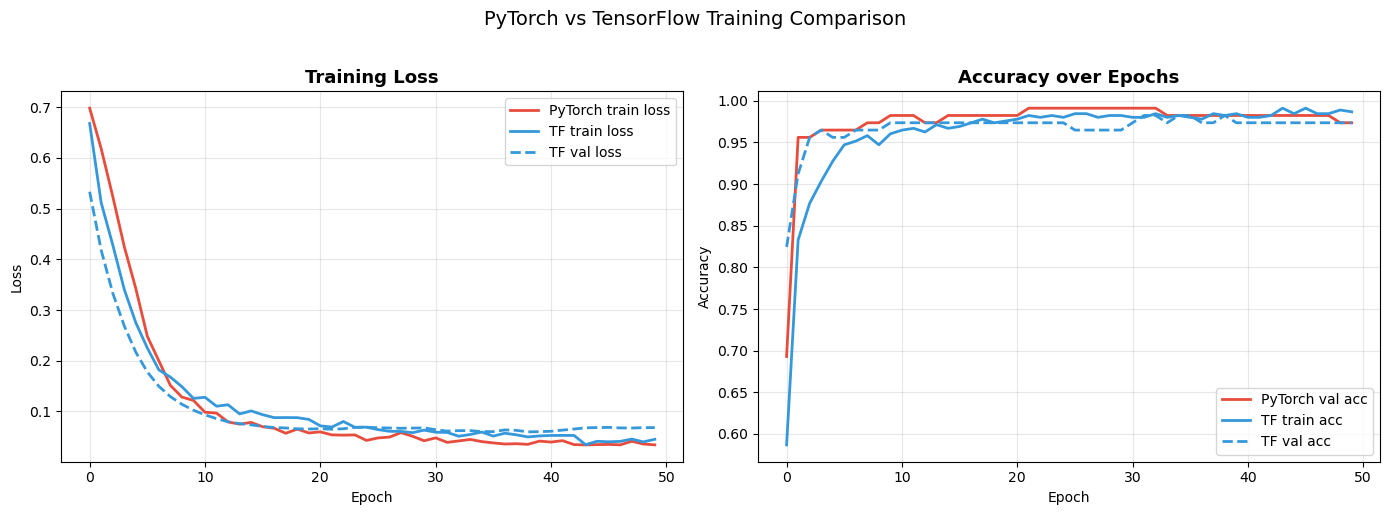

In [17]:
# ── Visualise Training Curves ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
ax.plot(pt_train_losses, label='PyTorch train loss',  color='#e74c3c', lw=2)
ax.plot(tf_history.history['loss'],     label='TF train loss',     color='#3498db', lw=2)
ax.plot(tf_history.history['val_loss'], label='TF val loss',       color='#3498db', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(pt_val_accs,                         label='PyTorch val acc',    color='#e74c3c', lw=2)
ax.plot(tf_history.history['accuracy'],      label='TF train acc',       color='#3498db', lw=2)
ax.plot(tf_history.history['val_accuracy'],  label='TF val acc',         color='#3498db', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('PyTorch vs TensorFlow Training Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. 📊 Evaluation & Metrics

After training, we evaluate the model's performance using metrics beyond simple accuracy.

In [18]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# ── PyTorch predictions ─────────────────────────────────────────
pt_cancer_model.eval()
with torch.no_grad():
    pt_probs = pt_cancer_model(X_te_pt).numpy().flatten()
pt_preds = (pt_probs > 0.5).astype(int)

# ── TensorFlow predictions ──────────────────────────────────────
tf_probs = tf_cancer_model.predict(X_test, verbose=0).flatten()
tf_preds = (tf_probs > 0.5).astype(int)

# ── Classification Report ──────────────────────────────────────
print("═══ PyTorch Classification Report ═══")
print(classification_report(y_test, pt_preds,
                             target_names=['Benign', 'Malignant']))

print("═══ TensorFlow Classification Report ═══")
print(classification_report(y_test, tf_preds,
                             target_names=['Benign', 'Malignant']))

═══ PyTorch Classification Report ═══
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97        43
   Malignant       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

═══ TensorFlow Classification Report ═══
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97        43
   Malignant       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



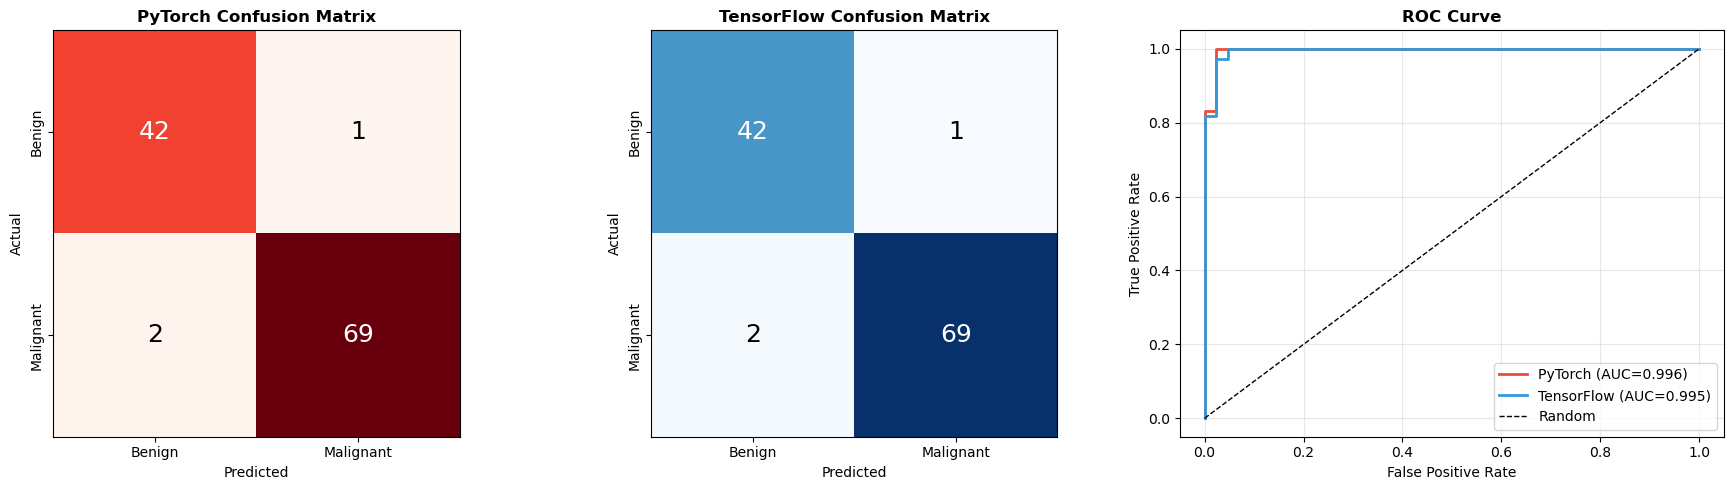

In [19]:
# ── Confusion Matrix + ROC Curve ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrices
for ax, preds, title, color in zip(
    axes[:2],
    [pt_preds, tf_preds],
    ['PyTorch', 'TensorFlow'],
    ['Reds', 'Blues']
):
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap=color)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Benign','Malignant'])
    ax.set_yticklabels(['Benign','Malignant'], rotation=90, va='center')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{title} Confusion Matrix', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    fontsize=18, color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC Curve
ax = axes[2]
for probs, label, color in [
    (pt_probs, 'PyTorch', '#e74c3c'),
    (tf_probs, 'TensorFlow', '#3498db')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. 💾 Saving & Loading Models

In [20]:
import os
os.makedirs('saved_models', exist_ok=True)

# ════════════════════════════════════
#  PyTorch — Save & Load
# ════════════════════════════════════

# Option A: Save only the weights (recommended)
torch.save(pt_cancer_model.state_dict(), 'saved_models/pt_model_weights.pth')
print("✅ PyTorch weights saved.")

# Load: recreate model, then load weights
loaded_pt = CancerNet(X_train.shape[1])
loaded_pt.load_state_dict(torch.load('saved_models/pt_model_weights.pth'))
loaded_pt.eval()

# Verify
with torch.no_grad():
    reloaded_pred = (loaded_pt(X_te_pt) > 0.5).float()
    reloaded_acc  = (reloaded_pred == y_te_pt).float().mean().item()
print(f"Reloaded PyTorch Accuracy: {reloaded_acc:.4f}\n")

# ════════════════════════════════════
#  TensorFlow — Save & Load
# ════════════════════════════════════

# Option A: Save full model (architecture + weights + optimizer)
tf_cancer_model.save('saved_models/tf_model.keras')
print("✅ TensorFlow full model saved.")

# Load
loaded_tf  = keras.models.load_model('saved_models/tf_model.keras')
tf_reload_loss, tf_reload_acc = loaded_tf.evaluate(X_test, y_test, verbose=0)
print(f"Reloaded TensorFlow Accuracy: {tf_reload_acc:.4f}")

✅ PyTorch weights saved.
Reloaded PyTorch Accuracy: 0.9737

✅ TensorFlow full model saved.
Reloaded TensorFlow Accuracy: 0.9737


---
## 9. ✅ Practice Tasks

Work through these tasks to solidify your understanding. Each task has a **description**, a **starter cell**, and a **solution cell** (hidden until you try!).

> 💡 **Tip**: Try to solve each task yourself before looking at the solution.

### 🎯 Task 1 — Tensor Operations
Create a 4×4 matrix of random integers between 0 and 9 using PyTorch.  
Then: (a) print its shape and dtype, (b) compute row-wise mean, (c) find the index of the maximum element.

In [21]:
# ── ✅ Task 1  ─────────────────────────────────────────

# (a) Create tensor
mat = torch.randint(0, 10, (4, 4))
print("Matrix:\n", mat.numpy())
print("Shape:", mat.shape, "| dtype:", mat.dtype)

# (b) Row-wise mean (need float for mean)
row_means = mat.float().mean(dim=1)
print("Row-wise means:", row_means.numpy().round(2))

# (c) Index of global max
flat_idx = mat.argmax().item()
row, col  = divmod(flat_idx, 4)
print(f"Max value {mat.max().item()} at position ({row}, {col})")

Matrix:
 [[2 8 2 7]
 [5 3 7 7]
 [3 0 5 7]
 [9 9 3 1]]
Shape: torch.Size([4, 4]) | dtype: torch.int64
Row-wise means: [4.75 5.5  3.75 5.5 ]
Max value 9 at position (3, 0)


### 🎯 Task 2 — Gradient Computation
Using PyTorch autograd, define `f(x) = sin(x²) + cos(x)`.  
Compute and print `df/dx` at `x = π/4`. Then verify numerically using finite differences.

In [22]:
# ── ✅ Task 2  ─────────────────────────────────────────
import math

x = torch.tensor(math.pi / 4, requires_grad=True)

# f(x) = sin(x²) + cos(x)
f = torch.sin(x**2) + torch.cos(x)
f.backward()
analytic_grad = x.grad.item()

# Analytical: df/dx = 2x·cos(x²) - sin(x)
xv = math.pi / 4
manual = 2 * xv * math.cos(xv**2) - math.sin(xv)

# Numerical: finite differences
h = 1e-5
f_plus  = math.sin((xv+h)**2) + math.cos(xv+h)
f_minus = math.sin((xv-h)**2) + math.cos(xv-h)
numerical_grad = (f_plus - f_minus) / (2 * h)

print(f"Autograd gradient      : {analytic_grad:.6f}")
print(f"Manual formula         : {manual:.6f}")
print(f"Finite differences     : {numerical_grad:.6f}")
print(f"All close? {abs(analytic_grad - numerical_grad) < 1e-4}")

Autograd gradient      : 0.574199
Manual formula         : 0.574199
Finite differences     : 0.574199
All close? True


### 🎯 Task 3 — Build a Regression Network (PyTorch)
Build and train a PyTorch model to **predict Boston-style housing prices** on the California Housing dataset.  
Use `MSELoss`, `Adam` optimizer, and plot the training loss curve.

Test RMSE: 0.8356 (units: $100k)


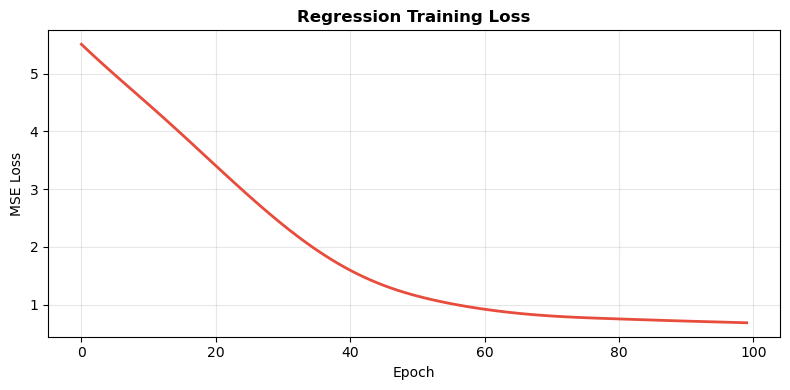

In [23]:
# ── ✅ Task 3  ─────────────────────────────────────────
from sklearn.datasets import fetch_california_housing

# Load data
housing = fetch_california_housing()
X_h = housing.data.astype(np.float32)
y_h = housing.target.astype(np.float32)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)
scaler_h = StandardScaler()
X_h_train = scaler_h.fit_transform(X_h_train)
X_h_test  = scaler_h.transform(X_h_test)

# Tensors
X_ht = torch.tensor(X_h_train, dtype=torch.float32)
y_ht = torch.tensor(y_h_train, dtype=torch.float32).unsqueeze(1)

# Model
reg_model = nn.Sequential(
    nn.Linear(8, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)   # no activation: regression output
)

criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(reg_model.parameters(), lr=1e-3)

reg_losses = []
for epoch in range(100):
    reg_model.train()
    optimizer_reg.zero_grad()
    out  = reg_model(X_ht)
    loss = criterion_reg(out, y_ht)
    loss.backward()
    optimizer_reg.step()
    reg_losses.append(loss.item())

# Evaluate on test
reg_model.eval()
with torch.no_grad():
    X_ht_test = torch.tensor(X_h_test, dtype=torch.float32)
    y_hat     = reg_model(X_ht_test).numpy().flatten()
mse_final = np.mean((y_hat - y_h_test)**2)
rmse      = np.sqrt(mse_final)
print(f"Test RMSE: {rmse:.4f} (units: $100k)")

plt.figure(figsize=(8, 4))
plt.plot(reg_losses, color='#e74c3c', lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Regression Training Loss', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 🎯 Task 4 — Multi-class Classification (TensorFlow)
Train a TensorFlow/Keras model to classify **iris flowers** into 3 species.  
Use `softmax` output, `sparse_categorical_crossentropy` loss, and report per-class accuracy.

Test Accuracy: 0.9667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



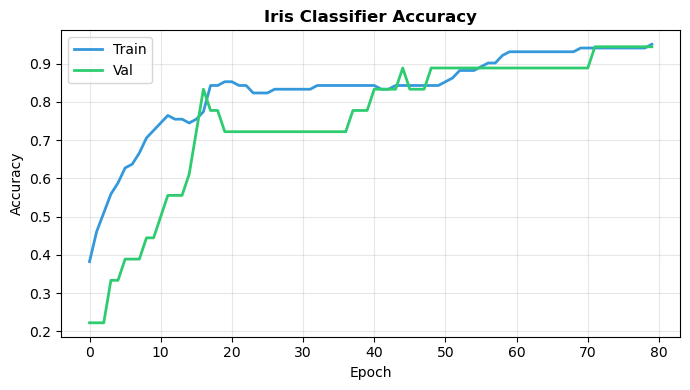

In [24]:
# ── ✅ Task 4  ─────────────────────────────────────────
from sklearn.datasets import load_iris

iris = load_iris()
X_ir = iris.data.astype(np.float32)
y_ir = iris.target                       # integer labels 0,1,2

X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    X_ir, y_ir, test_size=0.2, random_state=42
)
scaler_ir = StandardScaler()
X_ir_train = scaler_ir.fit_transform(X_ir_train)
X_ir_test  = scaler_ir.transform(X_ir_test)

iris_model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8,  activation='relu'),
    layers.Dense(3,  activation='softmax')   # 3 classes
], name='IrisClassifier')

iris_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

iris_hist = iris_model.fit(
    X_ir_train, y_ir_train,
    epochs=80, batch_size=16,
    validation_split=0.15, verbose=0
)

iris_loss, iris_acc = iris_model.evaluate(X_ir_test, y_ir_test, verbose=0)
iris_preds = iris_model.predict(X_ir_test, verbose=0).argmax(axis=1)

print(f"Test Accuracy: {iris_acc:.4f}\n")
print(classification_report(y_ir_test, iris_preds,
                             target_names=iris.target_names))

# Plot accuracy
plt.figure(figsize=(7, 4))
plt.plot(iris_hist.history['accuracy'],     label='Train', color='#3498db', lw=2)
plt.plot(iris_hist.history['val_accuracy'], label='Val',   color='#2ecc71', lw=2)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Iris Classifier Accuracy', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 🎯 Task 5 — Custom Training Loop (TensorFlow)
Replicate the TensorFlow training loop manually using `tf.GradientTape` (no `.fit()`).  
Train on the cancer dataset, print loss every 10 epochs, and compare with the `.fit()` result.

Epoch  10/50 | Loss: 0.4654
Epoch  20/50 | Loss: 0.3577
Epoch  30/50 | Loss: 0.2789
Epoch  40/50 | Loss: 0.2230
Epoch  50/50 | Loss: 0.1833

✅ Manual Training Loop Test Accuracy: 0.9649
   Original .fit() Test Accuracy    : 0.9737


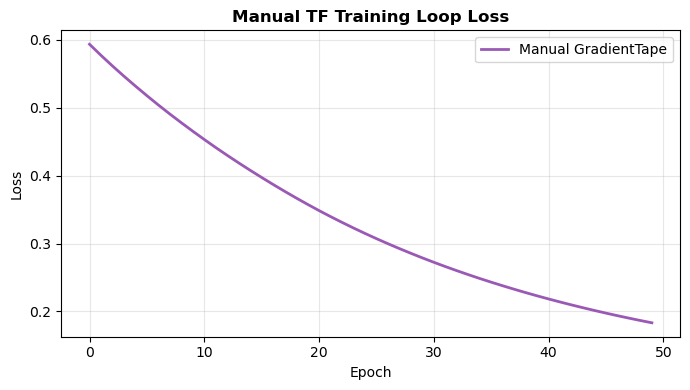

In [25]:
# ── ✅ Task 5  ─────────────────────────────────────────

# Fresh model
manual_tf_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

optimizer_manual = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn_manual   = keras.losses.BinaryCrossentropy()

X_tr_tf = tf.constant(X_train)
y_tr_tf = tf.constant(y_train)
X_te_tf = tf.constant(X_test)

EPOCHS = 50
manual_losses = []

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        preds = manual_tf_model(X_tr_tf, training=True)
        loss  = loss_fn_manual(y_tr_tf, tf.squeeze(preds))

    grads = tape.gradient(loss, manual_tf_model.trainable_variables)
    optimizer_manual.apply_gradients(
        zip(grads, manual_tf_model.trainable_variables)
    )
    manual_losses.append(loss.numpy())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {loss.numpy():.4f}")

# Test accuracy
manual_preds = (manual_tf_model.predict(X_te_tf, verbose=0).flatten() > 0.5).astype(int)
manual_acc   = (manual_preds == y_test).mean()
print(f"\n✅ Manual Training Loop Test Accuracy: {manual_acc:.4f}")
print(f"   Original .fit() Test Accuracy    : {tf_acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(manual_losses, color='#9b59b6', lw=2, label='Manual GradientTape')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Manual TF Training Loop Loss', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 🎯 Task 6 — Transfer Learning Preview (Bonus)
Freeze all layers of the TF cancer model except the last Dense layer.  
Retrain only the last layer for 20 more epochs. Compare with fine-tuning all layers.

In [26]:
# ── ✅ Task 6  ─────────────────────────────────────────
import copy

# Load a fresh copy of the saved model
transfer_model = keras.models.load_model('saved_models/tf_model.keras')

print("All layers:")
for i, layer in enumerate(transfer_model.layers):
    print(f"  [{i}] {layer.name:25s}  trainable={layer.trainable}")

# Freeze all but the last layer
for layer in transfer_model.layers[:-1]:
    layer.trainable = False

print("\nAfter freezing:")
for layer in transfer_model.layers:
    print(f"  {layer.name:25s}  trainable={layer.trainable}")

# Must recompile after changing trainable flags
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transfer_hist = transfer_model.fit(
    X_train, y_train, epochs=20,
    validation_data=(X_test, y_test), verbose=0
)

_, frozen_acc = transfer_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFrozen (last layer only) accuracy: {frozen_acc:.4f}")
print(f"Full model accuracy              : {tf_acc:.4f}")
print("\nKey insight: freezing pre-trained layers is the core of transfer learning!")

All layers:
  [0] dense_3                    trainable=True
  [1] dropout                    trainable=True
  [2] dense_4                    trainable=True
  [3] dense_5                    trainable=True

After freezing:
  dense_3                    trainable=False
  dropout                    trainable=False
  dense_4                    trainable=False
  dense_5                    trainable=True

Frozen (last layer only) accuracy: 0.9737
Full model accuracy              : 0.9737

Key insight: freezing pre-trained layers is the core of transfer learning!


---
### 🎯 Task 7 — Tensor Broadcasting & Normalization
Given a matrix of shape `(5, 4)` with random values, normalize **each column** to have mean=0 and std=1 (z-score normalization) **without using sklearn** — use only PyTorch tensor operations.
Verify by printing the column-wise mean and std of the result (should be ≈0 and ≈1).

In [27]:
# ── ✅ Task 7  ─────────────────────────────────────────
torch.manual_seed(42)
M = torch.randn(5, 4) * 10 + 5

col_mean = M.mean(dim=0)   # shape (4,)  — one mean per column
col_std  = M.std(dim=0)    # shape (4,)  — one std  per column

# Broadcasting: (5,4) - (4,)  →  (5,4)
M_norm = (M - col_mean) / col_std

print("Normalized column means:", M_norm.mean(dim=0).numpy().round(6))
print("Normalized column stds :", M_norm.std(dim=0).numpy().round(6))
print("\nNormalized matrix:\n", M_norm.numpy().round(4))
print("\nKey insight: subtracting/dividing a (4,) tensor from a (5,4)",
      "tensor works automatically via broadcasting!")

Normalized column means: [-0.  0.  0.  0.]
Normalized column stds : [1. 1. 1. 1.]

Normalized matrix:
 [[ 1.6553  1.2569  0.8214 -1.457 ]
 [-0.9134  0.8221  0.6718  1.1494]
 [ 0.1523 -1.0542 -1.2654  0.1587]
 [-0.4097 -0.2799 -0.9035  0.5844]
 [-0.4844 -0.7449  0.6757 -0.4354]]

Key insight: subtracting/dividing a (4,) tensor from a (5,4) tensor works automatically via broadcasting!


### 🎯 Task 8 — Implement a Custom Loss Function
Implement **Huber Loss** from scratch in both PyTorch and TensorFlow (no built-ins).  
Huber loss is less sensitive to outliers than MSE:
$$L_{\delta}(y, \hat{y}) = \begin{cases} \frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \le \delta \\ \delta \cdot |y-\hat{y}| - \frac{\delta^2}{2} & \text{otherwise} \end{cases}$$
Test it with some sample predictions and compare against PyTorch's built-in `HuberLoss`.

In [28]:
# ── ✅ Task 8  ─────────────────────────────────────────

# ── PyTorch custom Huber loss ──
def huber_loss_pt(y_true, y_pred, delta=1.0):
    err      = torch.abs(y_true - y_pred)
    quadratic = 0.5 * err**2
    linear    = delta * err - 0.5 * delta**2
    return torch.where(err <= delta, quadratic, linear).mean()

# ── TensorFlow custom Huber loss ──
def huber_loss_tf(y_true, y_pred, delta=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    err       = tf.abs(y_true - y_pred)
    quadratic = 0.5 * err**2
    linear    = delta * err - 0.5 * delta**2
    return tf.reduce_mean(tf.where(err <= delta, quadratic, linear))

y_true_sample = torch.tensor([1.0, 2.0, 3.0, 4.0, 100.0])
y_pred_sample = torch.tensor([1.1, 2.5, 2.8, 4.2,   5.0])

pt_custom   = huber_loss_pt(y_true_sample, y_pred_sample).item()
pt_builtin  = nn.HuberLoss()(y_pred_sample, y_true_sample).item()
tf_custom   = huber_loss_tf(y_true_sample.numpy(), y_pred_sample.numpy()).numpy()
mse_compare = nn.MSELoss()(y_pred_sample, y_true_sample).item()

print(f"PyTorch custom Huber : {pt_custom:.4f}")
print(f"PyTorch built-in Huber: {pt_builtin:.4f}  ← should match ✅")
print(f"TensorFlow custom    : {tf_custom:.4f}")
print(f"MSE (for comparison) : {mse_compare:.4f}  ← outlier inflates MSE!")
print("\nHuber loss is robust to the outlier (100.0), MSE is not.")

PyTorch custom Huber : 18.9340
PyTorch built-in Huber: 18.9340  ← should match ✅
TensorFlow custom    : 18.9340
MSE (for comparison) : 1805.0680  ← outlier inflates MSE!

Huber loss is robust to the outlier (100.0), MSE is not.


### 🎯 Task 9 — Learning Rate Comparison
Train three identical PyTorch models on the cancer dataset using **different learning rates**: `0.1`, `0.001`, `0.00001`.  
Plot all three loss curves on the same chart and explain which learning rate works best and why.

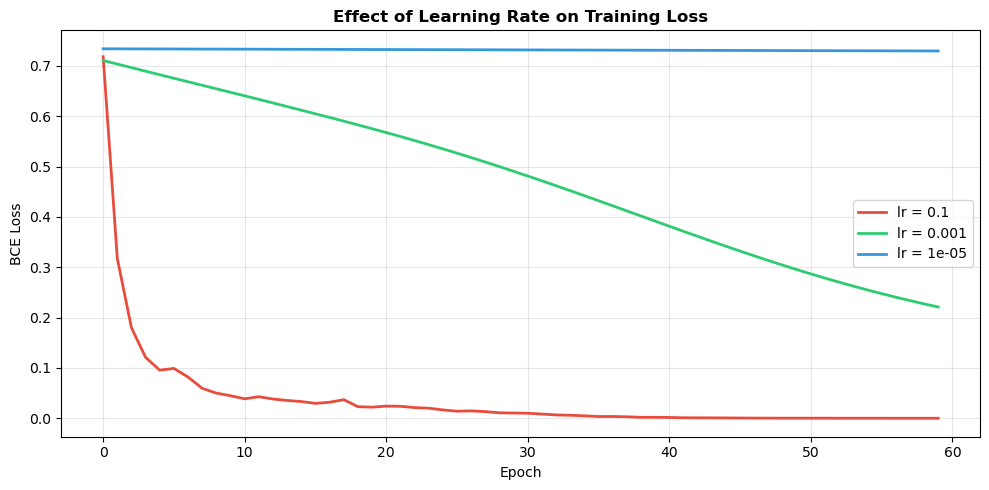

Analysis:
  lr=0.1      → Final loss: 0.0001  (too high: oscillates or diverges)
  lr=0.001    → Final loss: 0.2210  (just right: smooth, fast convergence)
  lr=0.00001  → Final loss: 0.7296  (too low: very slow, barely moved)


In [29]:
# ── ✅ Task 9  ─────────────────────────────────────────

def build_simple_pt():
    return nn.Sequential(
        nn.Linear(X_train.shape[1], 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, 1),  nn.Sigmoid()
    )

def train_model_lr(lr, epochs=60):
    model = build_simple_pt()
    opt   = optim.Adam(model.parameters(), lr=lr)
    crit  = nn.BCELoss()
    X_t   = torch.tensor(X_train)
    y_t   = torch.tensor(y_train).unsqueeze(1)
    losses = []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = crit(model(X_t), y_t)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

learning_rates = [0.1, 0.001, 0.00001]
colors = ['#e74c3c', '#2ecc71', '#3498db']
results = {lr: train_model_lr(lr) for lr in learning_rates}

plt.figure(figsize=(10, 5))
for lr, color in zip(learning_rates, colors):
    plt.plot(results[lr], label=f'lr = {lr}', color=color, lw=2)
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('Effect of Learning Rate on Training Loss', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Analysis:")
print(f"  lr=0.1      → Final loss: {results[0.1][-1]:.4f}  (too high: oscillates or diverges)")
print(f"  lr=0.001    → Final loss: {results[0.001][-1]:.4f}  (just right: smooth, fast convergence)")
print(f"  lr=0.00001  → Final loss: {results[0.00001][-1]:.4f}  (too low: very slow, barely moved)")

### 🎯 Task 10 — Dropout Regularization Experiment
Train two TensorFlow models on a **small noisy dataset** (200 samples):  
- **Model A**: no Dropout  
- **Model B**: with `Dropout(0.4)` after each hidden layer  

Plot train vs validation accuracy for both and explain which overfits more.

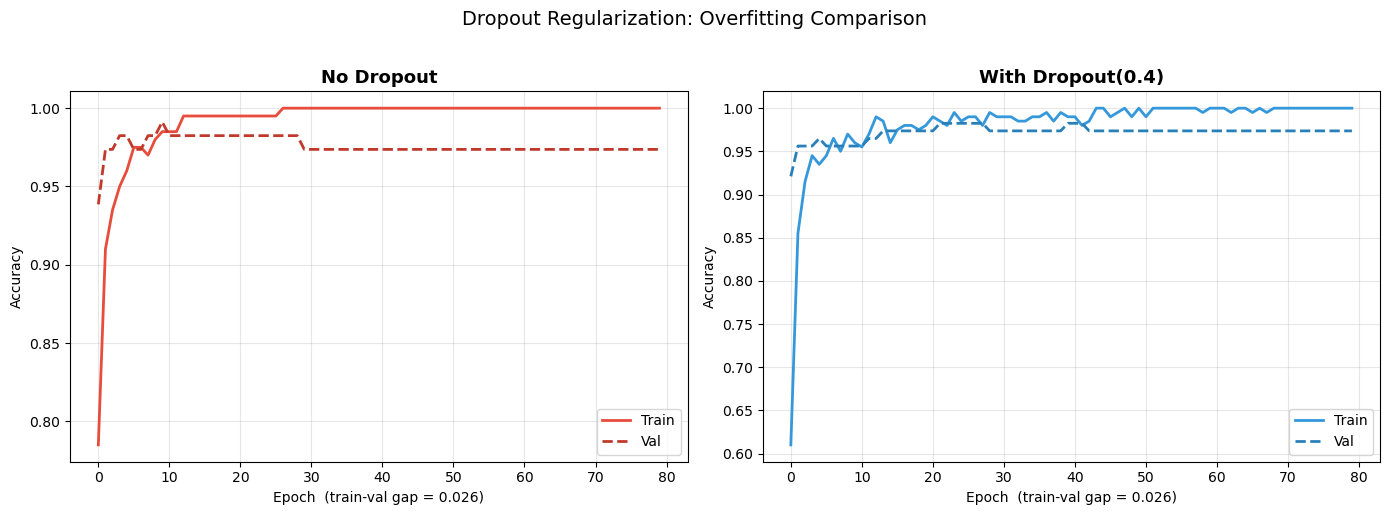

Observation: the model WITHOUT dropout shows a larger gap between train
and val accuracy — a clear sign of overfitting.


In [30]:
# ── ✅ Task 10  ────────────────────────────────────────

# Small dataset to force overfitting
X_small, y_small = X_train[:200], y_train[:200]

def make_model_tf(dropout_rate=0.0):
    inp = layers.Input(shape=(X_train.shape[1],))
    x   = layers.Dense(128, activation='relu')(inp)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x   = layers.Dense(64,  activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model_no_drop  = make_model_tf(dropout_rate=0.0)
model_with_drop = make_model_tf(dropout_rate=0.4)

hist_no   = model_no_drop.fit(X_small, y_small, epochs=80,
                               validation_data=(X_test, y_test), verbose=0)
hist_drop = model_with_drop.fit(X_small, y_small, epochs=80,
                                 validation_data=(X_test, y_test), verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, title, c_train, c_val in [
    (axes[0], hist_no,   'No Dropout',       '#e74c3c', '#c0392b'),
    (axes[1], hist_drop, 'With Dropout(0.4)','#3498db', '#2980b9')
]:
    ax.plot(hist.history['accuracy'],     label='Train', color=c_train, lw=2)
    ax.plot(hist.history['val_accuracy'], label='Val',   color=c_val,   lw=2, ls='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(alpha=0.3)
    final_gap = hist.history['accuracy'][-1] - hist.history['val_accuracy'][-1]
    ax.set_xlabel(f'Epoch  (train-val gap = {final_gap:.3f})')

plt.suptitle('Dropout Regularization: Overfitting Comparison', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print("Observation: the model WITHOUT dropout shows a larger gap between train")
print("and val accuracy — a clear sign of overfitting.")

### 🎯 Task 11 — Optimizer Comparison (Adam vs SGD vs RMSprop)
Train the same network architecture with three different optimizers in TensorFlow.  
Plot convergence speed and final validation accuracy to understand trade-offs.

Adam          final val acc: 0.9737
SGD+mom       final val acc: 0.9737
RMSprop       final val acc: 0.9737


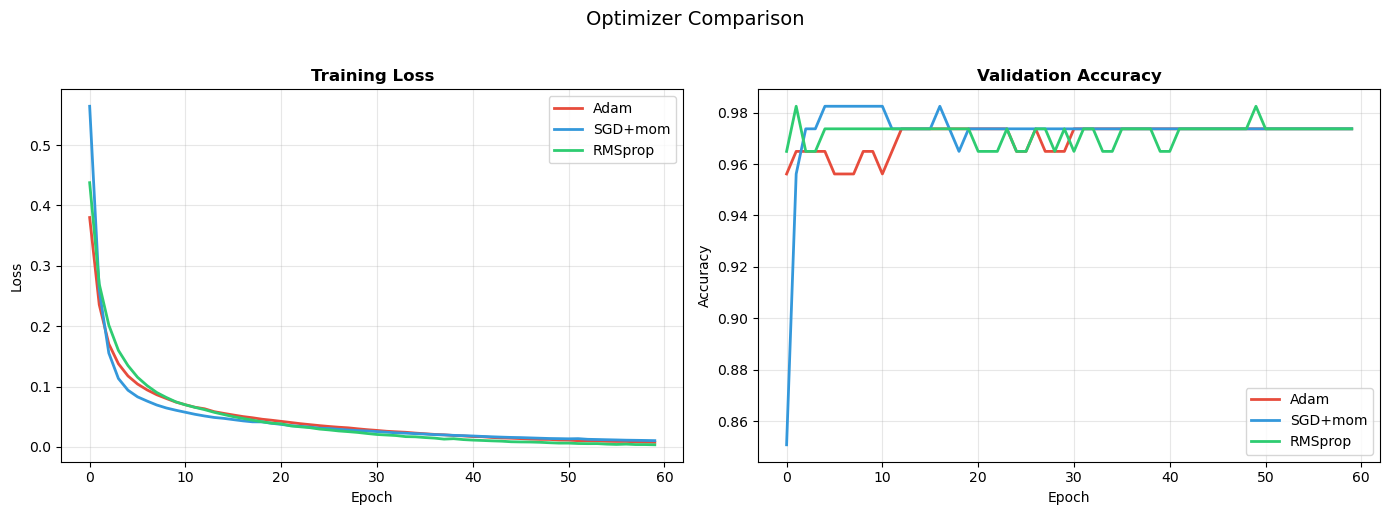

In [31]:
# ── ✅ Task 11  ────────────────────────────────────────

def build_and_train_opt(optimizer_obj, epochs=60):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer=optimizer_obj,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    hist = model.fit(X_train, y_train, epochs=epochs,
                     validation_data=(X_test, y_test), verbose=0)
    return hist

optimizers_cfg = [
    ('Adam',     keras.optimizers.Adam(0.001),       '#e74c3c'),
    ('SGD+mom',  keras.optimizers.SGD(0.01, momentum=0.9), '#3498db'),
    ('RMSprop',  keras.optimizers.RMSprop(0.001),    '#2ecc71'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, opt, color in optimizers_cfg:
    h = build_and_train_opt(opt)
    axes[0].plot(h.history['loss'],         label=name, color=color, lw=2)
    axes[1].plot(h.history['val_accuracy'], label=name, color=color, lw=2)
    print(f"{name:12s}  final val acc: {h.history['val_accuracy'][-1]:.4f}")

for ax, title, ylabel in [
    (axes[0], 'Training Loss',       'Loss'),
    (axes[1], 'Validation Accuracy', 'Accuracy')
]:
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Optimizer Comparison', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 🎯 Task 12 — Build a Network from Scratch (No Sequential)
Using PyTorch's `nn.Module`, build a **two-branch network** that:  
- Takes a single input `x` of shape `(N, 10)`
- Branch A: `Linear(10→16) → ReLU → Linear(16→8)`
- Branch B: `Linear(10→8)  → Tanh`
- Merges branches by **adding** them element-wise
- Final head: `Linear(8→1) → Sigmoid`

Run a forward pass and print the output shape.

In [32]:
# ── ✅ Task 12  ────────────────────────────────────────

class TwoBranchNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Branch A — deeper
        self.branch_a1 = nn.Linear(10, 16)
        self.branch_a2 = nn.Linear(16, 8)
        # Branch B — shallower
        self.branch_b  = nn.Linear(10, 8)
        # Final head
        self.head = nn.Sequential(nn.Linear(8, 1), nn.Sigmoid())

    def forward(self, x):
        a = torch.relu(self.branch_a1(x))
        a = torch.relu(self.branch_a2(a))   # shape (N, 8)
        b = torch.tanh(self.branch_b(x))    # shape (N, 8)
        merged = a + b                       # element-wise add
        return self.head(merged)             # shape (N, 1)

model_2b = TwoBranchNet()
x_dummy  = torch.randn(8, 10)
out      = model_2b(x_dummy)

print("Model architecture:")
print(model_2b)
print(f"\nInput  shape: {x_dummy.shape}")
print(f"Output shape: {out.shape}")
print(f"Output values: {out.detach().numpy().flatten().round(4)}")
total = sum(p.numel() for p in model_2b.parameters())
print(f"Total parameters: {total}")

Model architecture:
TwoBranchNet(
  (branch_a1): Linear(in_features=10, out_features=16, bias=True)
  (branch_a2): Linear(in_features=16, out_features=8, bias=True)
  (branch_b): Linear(in_features=10, out_features=8, bias=True)
  (head): Sequential(
    (0): Linear(in_features=8, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Input  shape: torch.Size([8, 10])
Output shape: torch.Size([8, 1])
Output values: [0.5349 0.5173 0.4594 0.3256 0.3427 0.4336 0.4818 0.3355]
Total parameters: 409


### 🎯 Task 13 — Early Stopping with Keras Callback
Train a TensorFlow model on the cancer dataset but use **Early Stopping** to automatically stop training when validation loss stops improving.  
Also add **Model Checkpoint** to save the best weights automatically.  
Print how many epochs actually ran vs the maximum.


Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 14.

────────────────────────────────────────
Max epochs set  : 200
Epochs actually run: 24  (saved 176 epochs!)
Best val loss at epoch 14
Test accuracy   : 0.9649


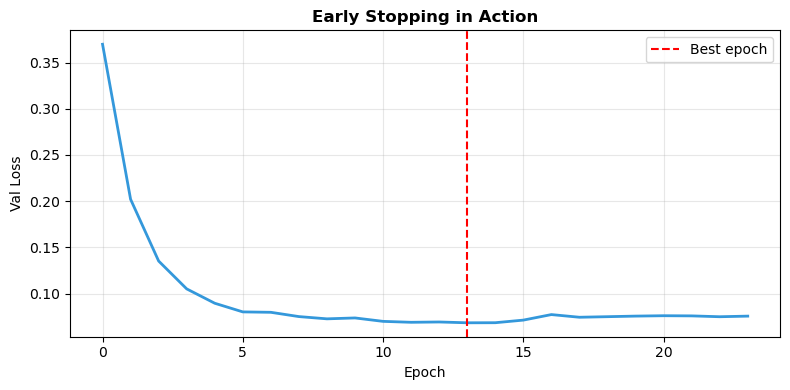

In [33]:
# ── ✅ Task 13  ────────────────────────────────────────
import os
os.makedirs('saved_models', exist_ok=True)

es_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
es_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)
checkpoint = keras.callbacks.ModelCheckpoint(
    'saved_models/best_es_model.keras',
    monitor='val_loss', save_best_only=True, verbose=0
)
lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1
)

MAX_EPOCHS = 200
es_hist = es_model.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint, lr_schedule],
    verbose=0
)

actual_epochs = len(es_hist.history['val_loss'])
_, es_acc = es_model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'─'*40}")
print(f"Max epochs set  : {MAX_EPOCHS}")
print(f"Epochs actually run: {actual_epochs}  (saved {MAX_EPOCHS - actual_epochs} epochs!)")
print(f"Best val loss at epoch {np.argmin(es_hist.history['val_loss'])+1}")
print(f"Test accuracy   : {es_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(es_hist.history['val_loss'], color='#3498db', lw=2)
plt.axvline(np.argmin(es_hist.history['val_loss']), color='red',
            ls='--', label='Best epoch')
plt.xlabel('Epoch'); plt.ylabel('Val Loss')
plt.title('Early Stopping in Action', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 🎯 Task 14 — Batch Normalization Effect
Compare training stability **with and without Batch Normalization** in PyTorch.  
Use a deeper network (5 hidden layers). Train both for 80 epochs on the cancer dataset.  
Plot the gradient norms of the first layer across epochs to show vanishing gradient behavior.

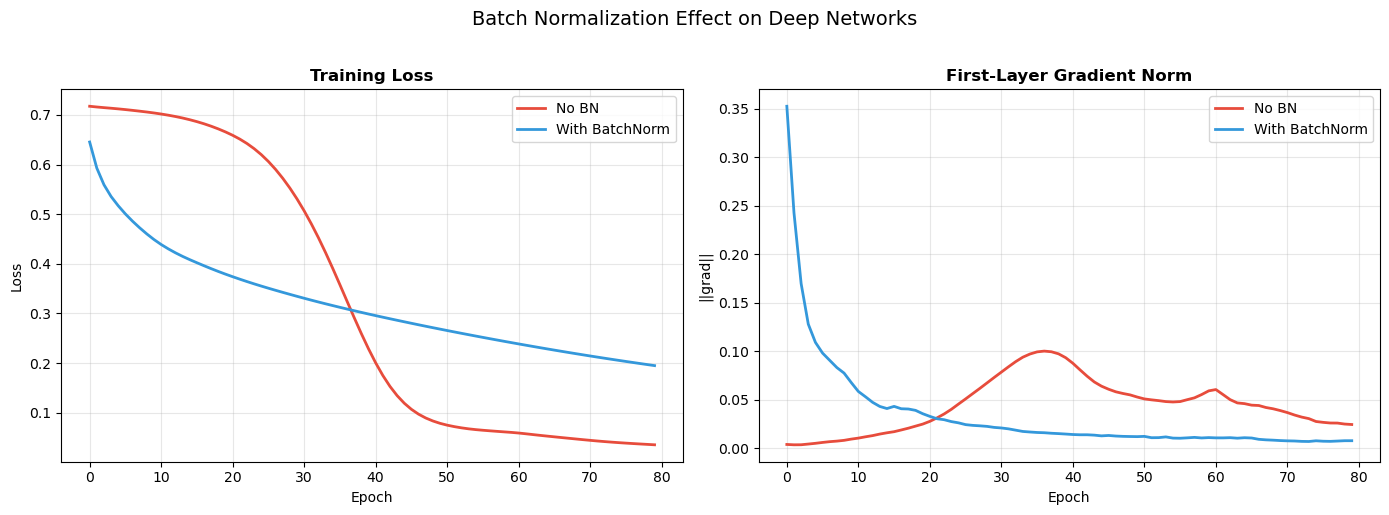

BatchNorm keeps gradient norms stable — preventing vanishing/exploding gradients.


In [34]:
# ── ✅ Task 14  ────────────────────────────────────────

class DeepNet(nn.Module):
    def __init__(self, use_bn=False, n_in=30):
        super().__init__()
        layers_list = []
        sizes = [n_in, 64, 64, 64, 32, 16]
        for i in range(len(sizes)-1):
            layers_list.append(nn.Linear(sizes[i], sizes[i+1]))
            if use_bn:
                layers_list.append(nn.BatchNorm1d(sizes[i+1]))
            layers_list.append(nn.ReLU())
        layers_list += [nn.Linear(16, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers_list)

    def forward(self, x):
        return self.net(x)

def train_record_grads(use_bn, epochs=80):
    model   = DeepNet(use_bn=use_bn, n_in=X_train.shape[1])
    opt     = optim.Adam(model.parameters(), lr=1e-3)
    crit    = nn.BCELoss()
    X_t     = torch.tensor(X_train)
    y_t     = torch.tensor(y_train).unsqueeze(1)
    grad_norms, losses = [], []

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = crit(model(X_t), y_t)
        loss.backward()
        # Grab gradient norm of first Linear layer
        first_linear = [m for m in model.net if isinstance(m, nn.Linear)][0]
        grad_norms.append(first_linear.weight.grad.norm().item())
        opt.step()
        losses.append(loss.item())
    return losses, grad_norms

losses_no_bn, grads_no_bn = train_record_grads(use_bn=False)
losses_bn,    grads_bn    = train_record_grads(use_bn=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses_no_bn, label='No BN',       color='#e74c3c', lw=2)
axes[0].plot(losses_bn,    label='With BatchNorm', color='#3498db', lw=2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(grads_no_bn, label='No BN',       color='#e74c3c', lw=2)
axes[1].plot(grads_bn,    label='With BatchNorm', color='#3498db', lw=2)
axes[1].set_title('First-Layer Gradient Norm', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('||grad||')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Batch Normalization Effect on Deep Networks', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print("BatchNorm keeps gradient norms stable — preventing vanishing/exploding gradients.")

### 🎯 Task 15 — End-to-End Mini Project (Both Frameworks)
**Diabetes Progression Prediction** — a full pipeline from scratch using sklearn's built-in diabetes dataset:
1. Load the Diabetes dataset (442 patients, 10 medical features)
2. Preprocess: scale features, binarize labels (progression above median → high risk)
3. Train **both** a PyTorch model and a TensorFlow model
4. Compare: Accuracy, Precision, Recall, F1, AUC
5. Print a final side-by-side summary table and visualise results

Dataset : Diabetes (sklearn)
Samples : 442 | Features: 10
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Label   : disease progression above median → 1 (high risk)
Class balance: 221 high-risk / 221 low-risk


════════════════════════════════════════════════════
Metric              PyTorch     TensorFlow Winner
────────────────────────────────────────────────────
Accuracy             0.7753         0.7528    PT 
Precision            0.7381         0.7143    PT 
Recall               0.7750         0.7500    PT 
F1 Score             0.7561         0.7317    PT 
AUC-ROC              0.8612         0.8398    PT 
════════════════════════════════════════════════════


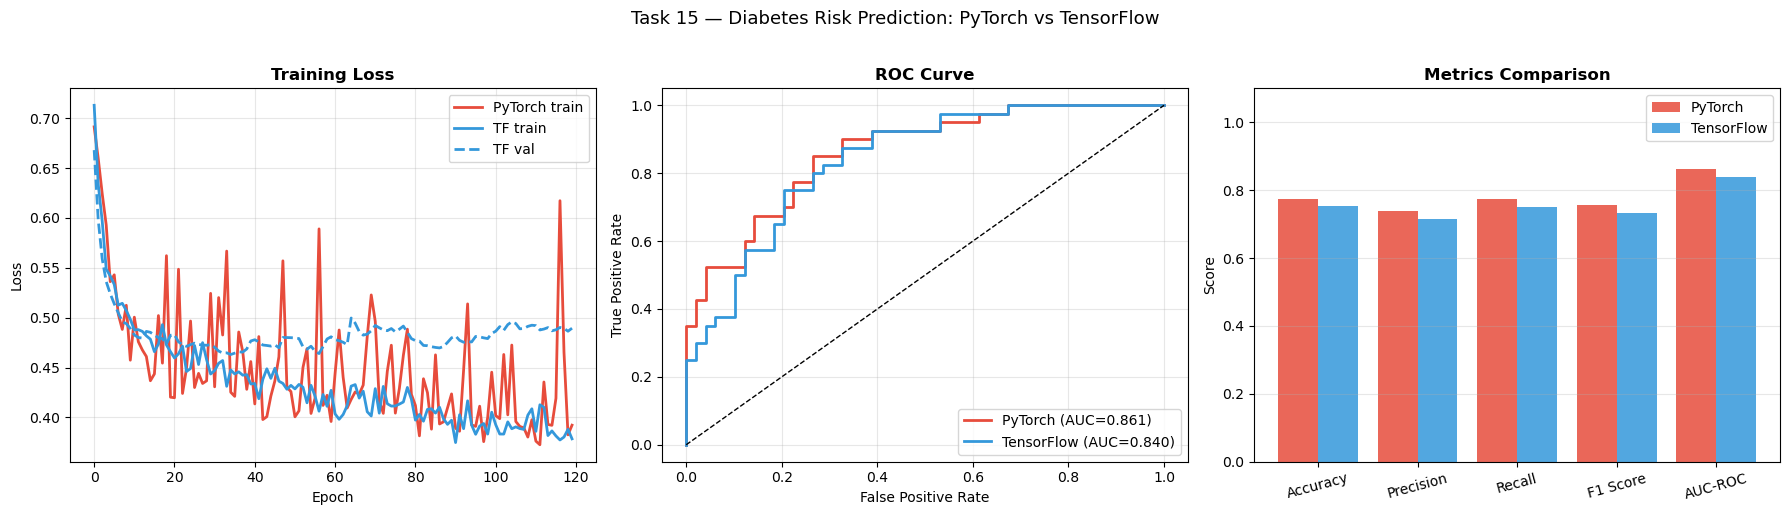

In [35]:
# ── ✅ Task 15  ────────────────────────────────────────
from sklearn.datasets import load_diabetes
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── 1. Load & prepare data ─────────────────────────────────────
diab   = load_diabetes()
X_d    = diab.data.astype(np.float32)
y_cont = diab.target                                # continuous 25–346
y_d    = (y_cont > np.median(y_cont)).astype(np.float32)  # binary: high risk

print("Dataset : Diabetes (sklearn)")
print(f"Samples : {X_d.shape[0]} | Features: {X_d.shape[1]}")
print(f"Features: {diab.feature_names}")
print(f"Label   : disease progression above median → 1 (high risk)")
print(f"Class balance: {int(y_d.sum())} high-risk / {int((1-y_d).sum())} low-risk\n")

# ── 2. Split & scale ──────────────────────────────────────────
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)
sc_d   = StandardScaler()
X_d_tr = sc_d.fit_transform(X_d_tr)
X_d_te = sc_d.transform(X_d_te)

# ── 3. PyTorch model ──────────────────────────────────────────
diab_pt = nn.Sequential(
    nn.Linear(10, 64),  nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 32),  nn.ReLU(),
    nn.Linear(32, 1),   nn.Sigmoid()
)
opt_d  = optim.Adam(diab_pt.parameters(), lr=1e-3)
crit_d = nn.BCELoss()
X_dt   = torch.tensor(X_d_tr.astype(np.float32))
y_dt   = torch.tensor(y_d_tr).unsqueeze(1)
ds_d   = TensorDataset(X_dt, y_dt)
dl_d   = DataLoader(ds_d, batch_size=32, shuffle=True)

pt_d_losses = []
for epoch in range(120):
    diab_pt.train()
    ep_loss = 0
    for xb, yb in dl_d:
        opt_d.zero_grad()
        loss = crit_d(diab_pt(xb), yb)
        loss.backward(); opt_d.step()
        ep_loss += loss.item()
    pt_d_losses.append(ep_loss / len(dl_d))

diab_pt.eval()
with torch.no_grad():
    pt_d_probs = diab_pt(torch.tensor(X_d_te.astype(np.float32))).numpy().flatten()
pt_d_preds = (pt_d_probs > 0.5).astype(int)

# ── 4. TensorFlow model ───────────────────────────────────────
diab_tf = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
diab_tf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tf_d_hist = diab_tf.fit(X_d_tr, y_d_tr, epochs=120,
                         validation_data=(X_d_te, y_d_te), verbose=0)
tf_d_probs = diab_tf.predict(X_d_te, verbose=0).flatten()
tf_d_preds = (tf_d_probs > 0.5).astype(int)

# ── 5. Metrics comparison ─────────────────────────────────────
def metrics_dict(y_true, y_pred, y_prob):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_true, y_prob),
    }

pt_m = metrics_dict(y_d_te, pt_d_preds, pt_d_probs)
tf_m = metrics_dict(y_d_te, tf_d_preds, tf_d_probs)

print("\n" + "═"*52)
print(f"{'Metric':<12} {'PyTorch':>14} {'TensorFlow':>14} {'Winner':>6}")
print("─"*52)
for metric in pt_m:
    winner = 'PT ' if pt_m[metric] > tf_m[metric] else ('TF ' if tf_m[metric] > pt_m[metric] else 'TIE')
    print(f"{metric:<12} {pt_m[metric]:>14.4f} {tf_m[metric]:>14.4f} {winner:>6}")
print("═"*52)

# ── 6. Visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(pt_d_losses,                  label='PyTorch train', color='#e74c3c', lw=2)
axes[0].plot(tf_d_hist.history['loss'],    label='TF train',      color='#3498db', lw=2)
axes[0].plot(tf_d_hist.history['val_loss'],label='TF val',        color='#3498db', lw=2, ls='--')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ROC Curves
for probs, label, color in [(pt_d_probs,'PyTorch','#e74c3c'),(tf_d_probs,'TensorFlow','#3498db')]:
    fpr, tpr, _ = roc_curve(y_d_te, probs)
    auc = roc_auc_score(y_d_te, probs)
    axes[1].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, lw=2)
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Bar chart of metrics
metric_names = list(pt_m.keys())
x = np.arange(len(metric_names))
axes[2].bar(x - 0.2, list(pt_m.values()), 0.4, label='PyTorch',    color='#e74c3c', alpha=0.85)
axes[2].bar(x + 0.2, list(tf_m.values()), 0.4, label='TensorFlow', color='#3498db', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(metric_names, rotation=15)
axes[2].set_ylim(0, 1.1); axes[2].set_ylabel('Score')
axes[2].set_title('Metrics Comparison', fontweight='bold')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Task 15 — Diabetes Risk Prediction: PyTorch vs TensorFlow', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 🎓 Summary — Key Concepts Covered

| Concept | PyTorch | TensorFlow |
|---------|---------|------------|
| Create tensor | `torch.tensor()`, `torch.rand()` | `tf.constant()`, `tf.random.uniform()` |
| Track gradients | `requires_grad=True` + `.backward()` | `tf.GradientTape()` |
| Define model | `class Net(nn.Module)` | `keras.Sequential([...])` |
| Loss function | `nn.BCELoss()`, `nn.MSELoss()` | `'binary_crossentropy'`, `'mse'` |
| Optimizer | `optim.Adam(params, lr=...)` | `keras.optimizers.Adam(lr=...)` |
| Training | Manual loop + `.backward()` | `.fit(X, y, epochs=...)` |
| Evaluate | Manual with `torch.no_grad()` | `.evaluate(X_test, y_test)` |
| Save model | `torch.save(state_dict)` | `model.save(path)` |
| Load model | `model.load_state_dict(torch.load(...))` | `keras.models.load_model(path)` |

### 📚 Next Steps
- **Convolutional Neural Networks (CNNs)** — for image data
- **Recurrent Neural Networks (RNNs / LSTMs)** — for sequences/text
- **Transfer Learning** — using pre-trained models (ResNet, BERT)
- **PyTorch Lightning** — structured PyTorch training
- **Keras Functional API** — complex multi-input/output architectures

---
*Happy Learning! 🚀*